# Week 03 (Module 14) - BBO capstone driver

Round 3. Five of the eight new bests came back last week and they're the spine of this round's plan.

**Confirmed wins from W2 → exploit:**
- **f4**: -4.03 → 0.26 → **0.54** under EI. Beat the +0.1 threshold pre-committed in W2, switch to **PI**.
- **f5**: 1089 → 1617 → **8662** at the all-1s corner — 5.4×. Switch to **PI**; expect it to either re-propose (1,1,1,1) (confirmation) or nudge just inside the corner.

**Confirmed wins under explore-family → stay on what's working:**
- **f6, f7**: UCB(β=3) found new bests, no reason to change. Stay UCB.
- **f8**: MES delivered (9.60 → 9.89), exactly the result that justified switching from UCB last week. Stay MES.

**The misses from W2:**
- **f1**: variance probe still landed in the zero field. Stay on variance — nothing to exploit yet.
- **f2**: Thompson missed (0.586 < incumbent 0.611). W2 pre-commit said try **augmented-EI** (noise-aware EI) next. New acquisition `aei` added to bo.py for this.
- **f3**: UCB returned -0.167. Stay UCB; the 3D box is still poorly sampled at 17 points.

**Headline shift this round: 4/8 functions move to exploit (PI / EI / MES).** The mix is now 4:4 explore:exploit vs 6:2 last week.


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

# --- settings for this week ---
WEEK = 3
KIND = "matern"
SEED = 0

# Acquisition modes carried forward.
EXPLORE  = dict(acq="ucb", beta=3.0)       # chase uncertainty - default mapping rule
BALANCED = dict(acq="ei",  xi=0.01)        # Expected Improvement
OPTIMISE = dict(acq="pi",  xi=0.0)         # greedy - squeeze around the current best
PROBE    = dict(acq="var")                 # pure max-entropy probing
THOMPSON = dict(acq="thompson")            # joint posterior sample
INFO     = dict(acq="mes")                 # Max-value Entropy Search
AUG_EI   = dict(acq="aei", xi=0.01)        # NEW this week: noise-aware EI for f2

# This week's plan: shift 4 functions to exploit, keep 4 in explore-family.
PLAN = {}
PLAN[1] = dict(PROBE)          # f1 still flat - keep probing
PLAN[2] = dict(AUG_EI)         # f2 Thompson missed - try noise-aware EI
PLAN[3] = dict(EXPLORE)        # f3 still under-sampled in 3D
PLAN[4] = dict(OPTIMISE)       # f4 confirmed exploit - tighten with PI
PLAN[5] = dict(OPTIMISE)       # f5 corner peak confirmed - PI to re-probe / nudge
PLAN[6] = dict(EXPLORE)        # f6 marginal UCB win - keep UCB
PLAN[7] = dict(EXPLORE)        # f7 UCB win - stay UCB
PLAN[8] = dict(INFO)           # f8 MES delivered - stay MES

OUTDIR = f"outputs/week{WEEK:02d}"
os.makedirs(OUTDIR, exist_ok=True)
pd.DataFrame([dict(func=f"f{fid}", **PLAN[fid]) for fid in bo.FUNC_IDS])


,func,acq,xi,beta
0,f1,var,NaN,NaN
1,f2,aei,0.01,NaN
2,f3,ucb,NaN,3.0
3,f4,pi,0.00,NaN
4,f5,pi,0.00,NaN
5,f6,ucb,NaN,3.0
6,f7,ucb,NaN,3.0
7,f8,mes,NaN,NaN


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
results = {fid: bo.run_function(fid, kind=KIND, seed=SEED, **PLAN[fid]) for fid in bo.FUNC_IDS}

summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4),
         pred_std=round(results[fid]["std"], 4),
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary

,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,12,0.0000,-0.0003,0.0010,var,0.077121-0.492948
1,f2,2,12,0.6112,0.4881,0.1350,aei,0.744832-0.040605
2,f3,3,17,-0.0348,-0.0641,0.0780,ucb,0.883990-0.828081-0.850814
3,f4,4,32,0.5401,0.5432,0.0137,pi,0.406314-0.415946-0.349326-0.438615
4,f5,4,22,8662.4050,8662.4560,2.5455,pi,0.999999-0.999999-0.999999-0.999999
5,f6,5,22,-0.7048,-1.1093,0.4309,ucb,0.341538-0.000000-0.999999-0.999999-0.999999
6,f7,6,32,1.6876,1.4746,0.1795,ucb,0.000000-0.999999-0.949660-0.000000-0.348297-0...
7,f8,8,42,9.8891,9.9819,0.0728,mes,0.121841-0.149133-0.117363-0.214605-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])

,func,ei,ucb,pi,var
0,f1,0.0000,0.0017,0.0000,0.0000
1,f2,0.0116,0.7582,0.1621,0.0182
2,f3,0.0153,0.1698,0.3071,0.0061
3,f4,0.0072,0.5706,0.5901,0.0002
4,f5,1.0412,8667.5470,0.5080,6.4795
5,f6,0.0386,0.1835,0.1681,0.1857
6,f7,0.0092,2.0131,0.1071,0.0322
7,f8,0.0875,10.1276,0.8723,0.0053


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

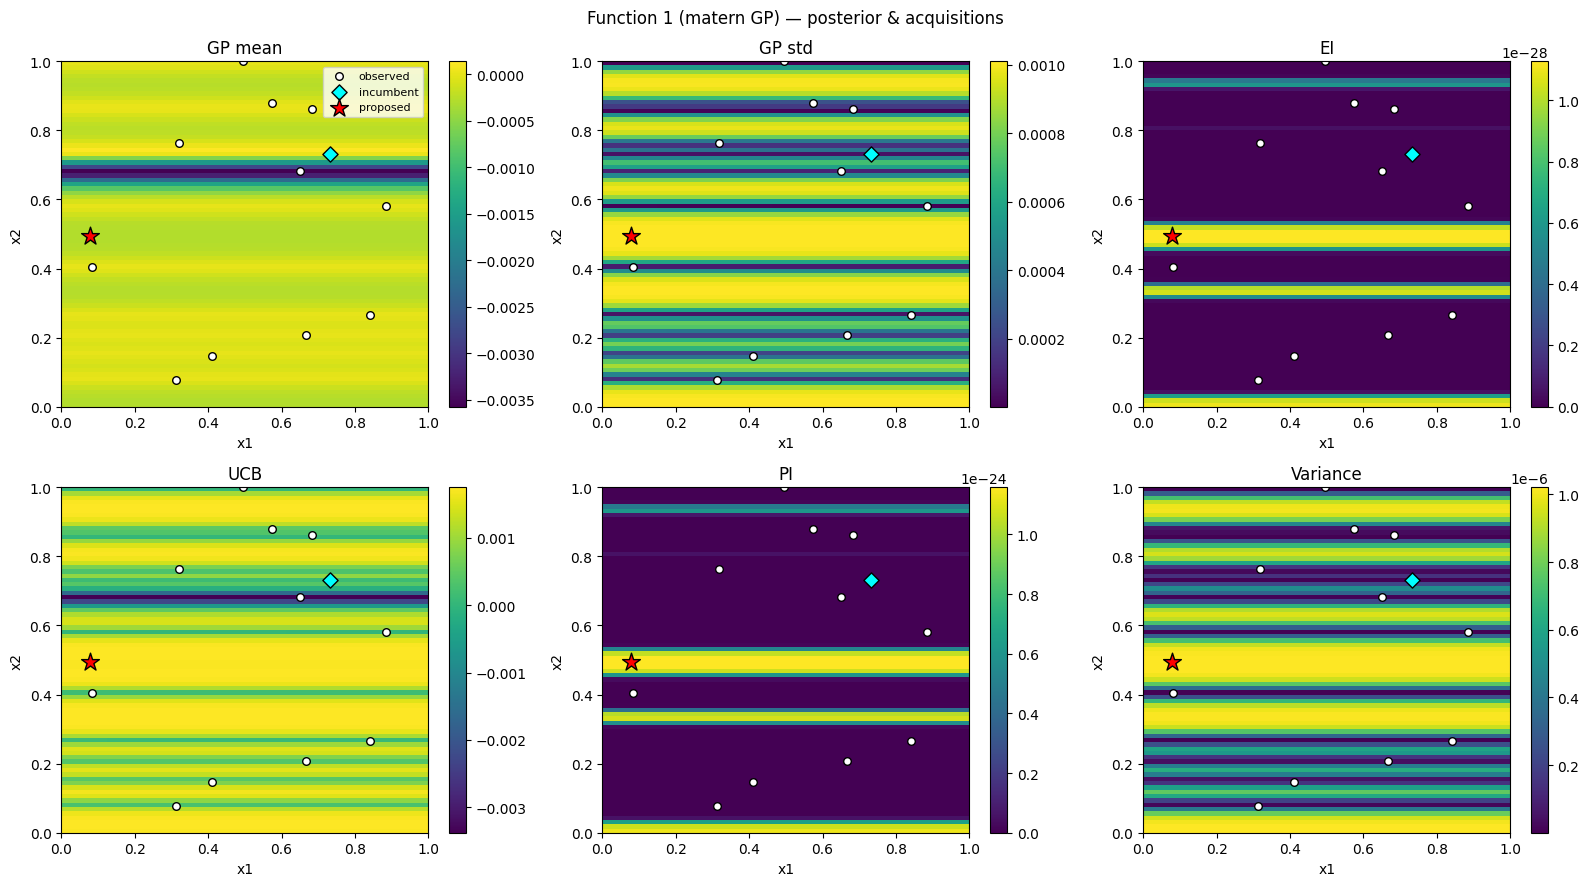

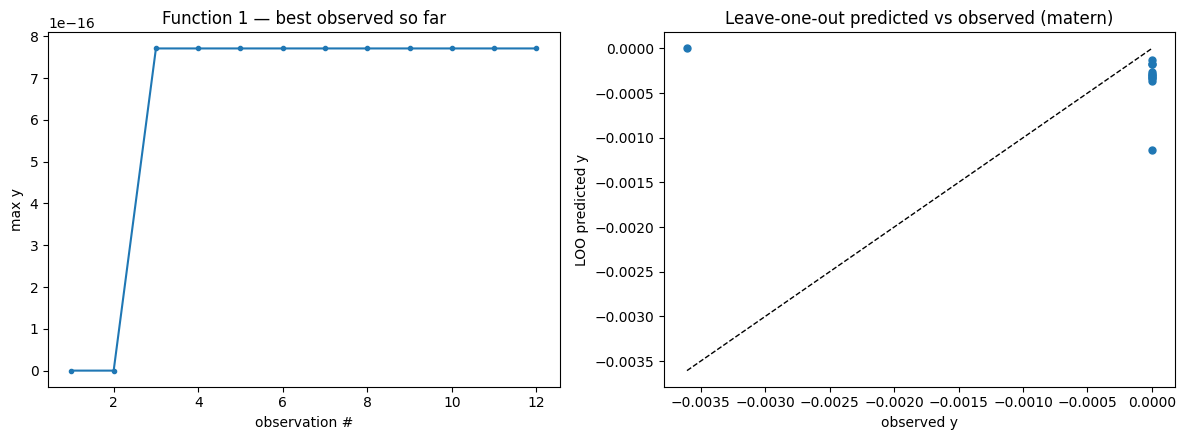

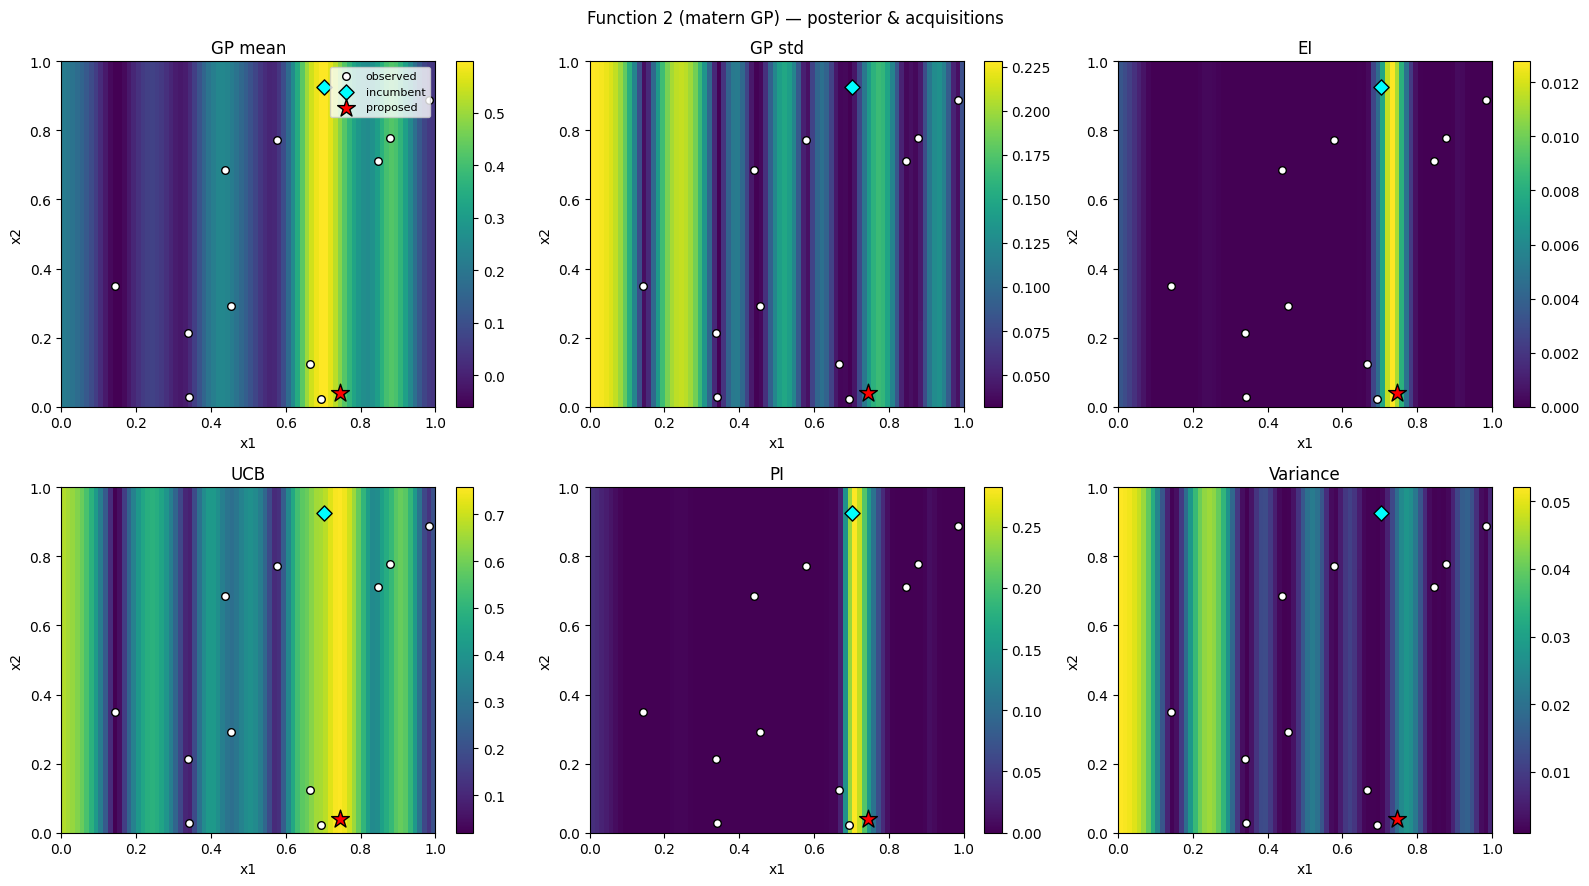

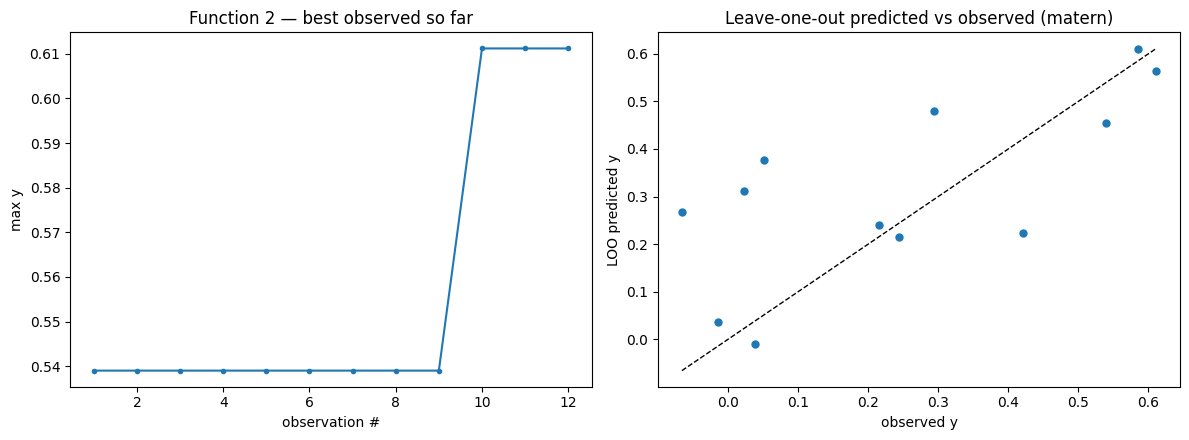

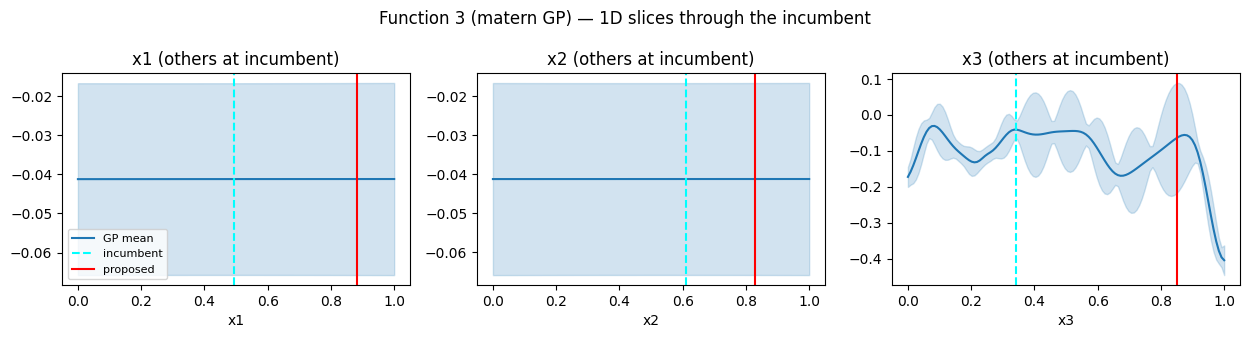

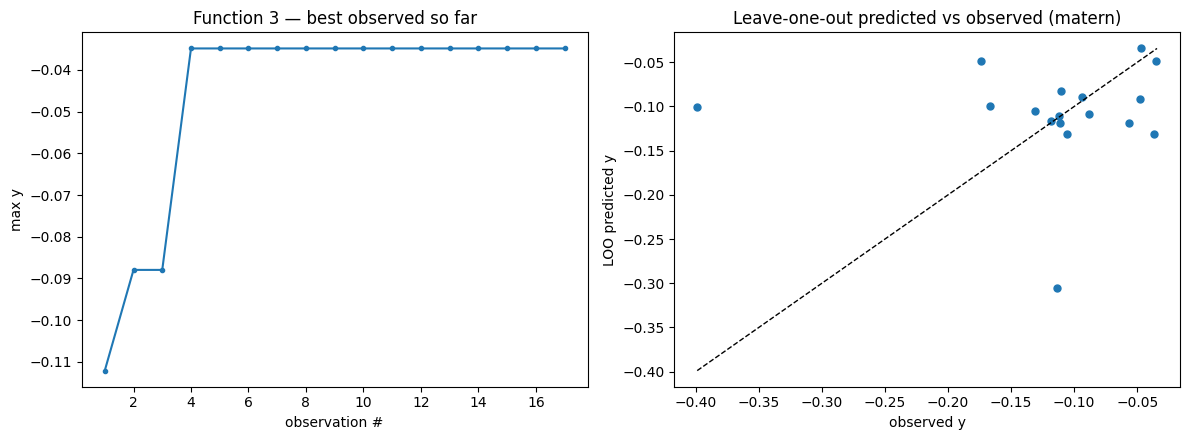

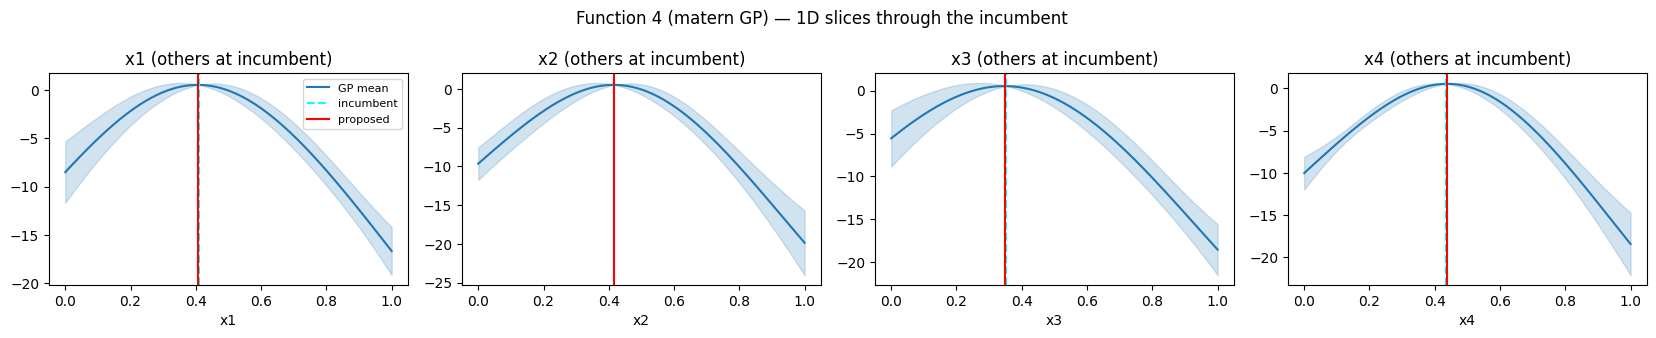

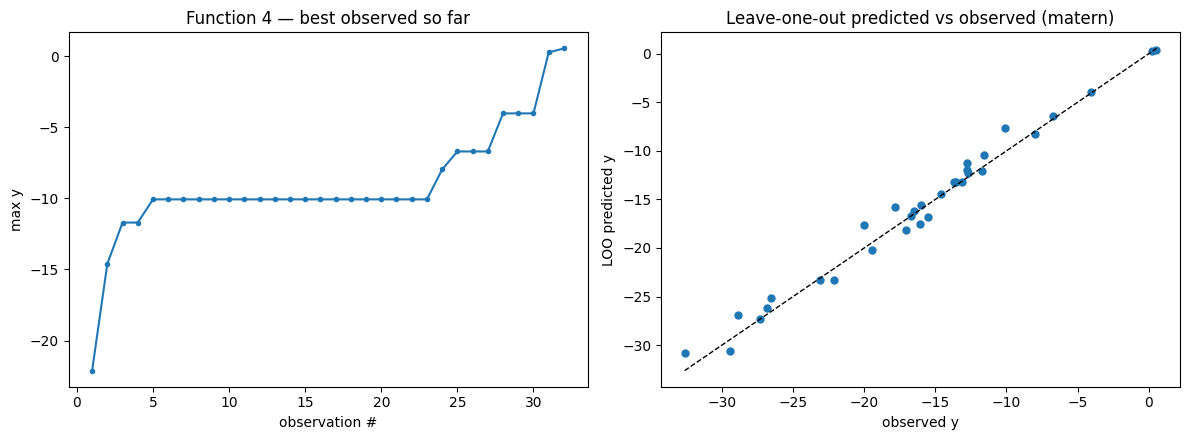

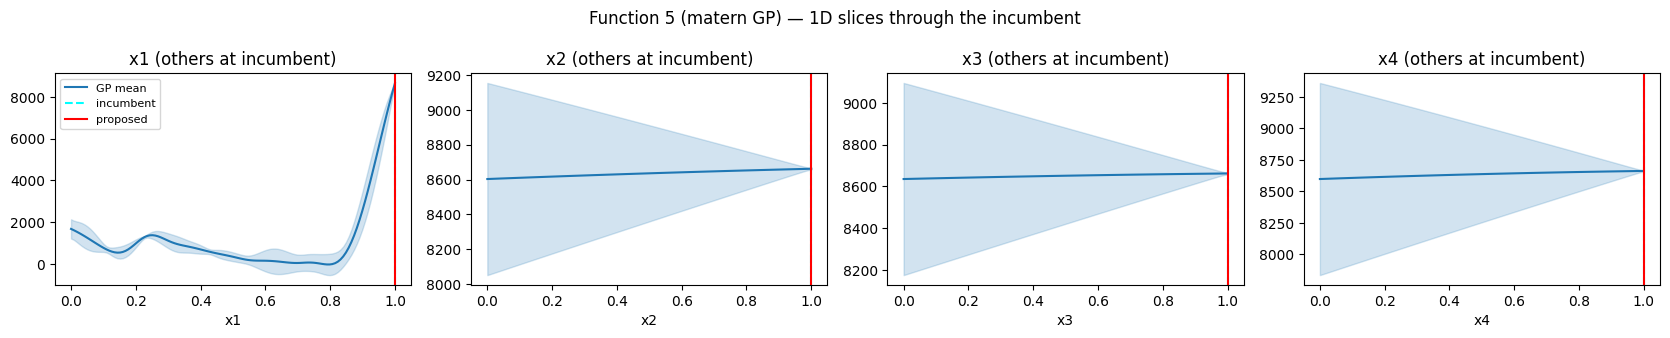

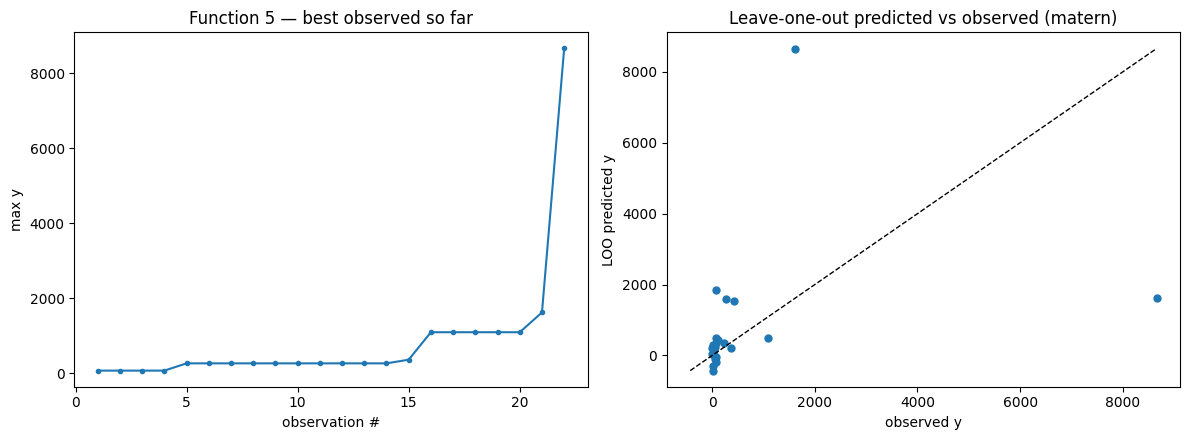

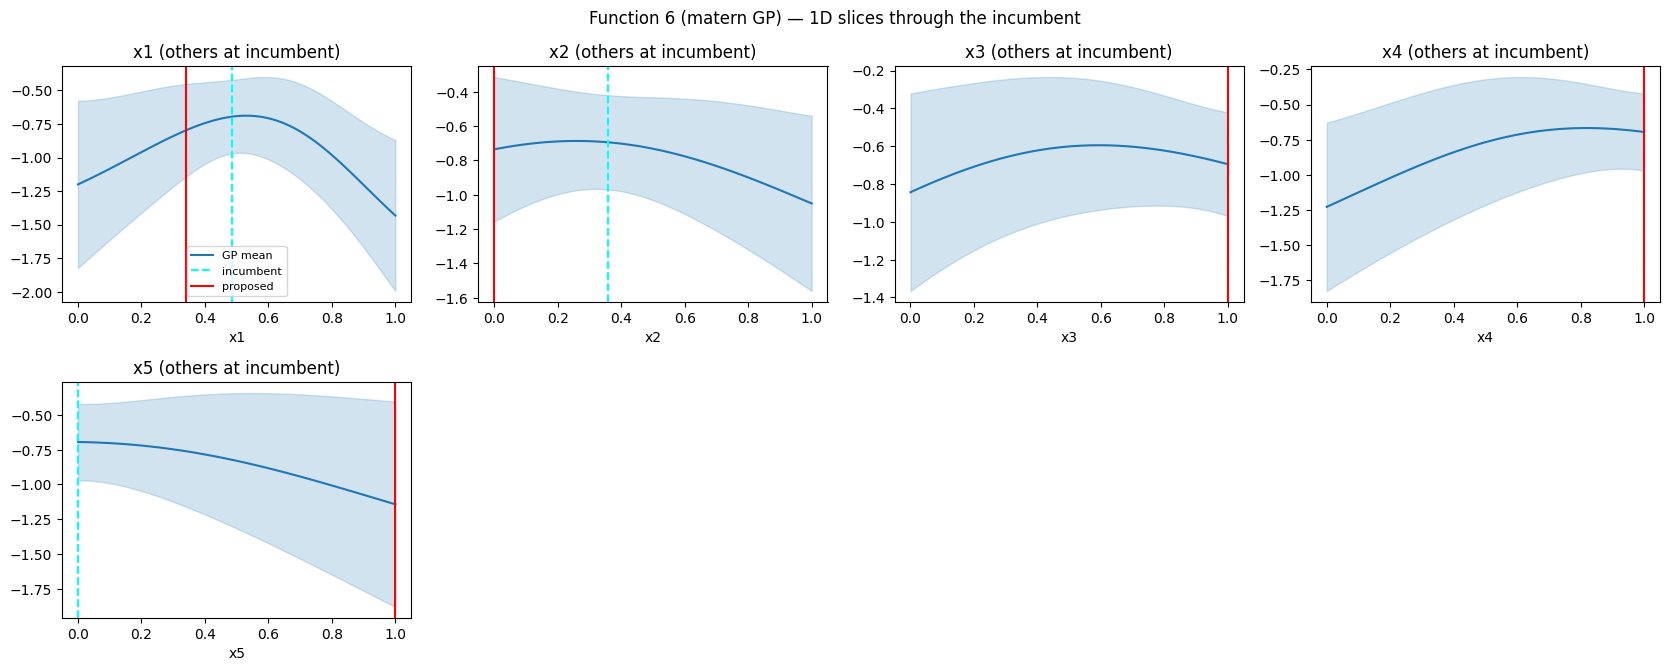

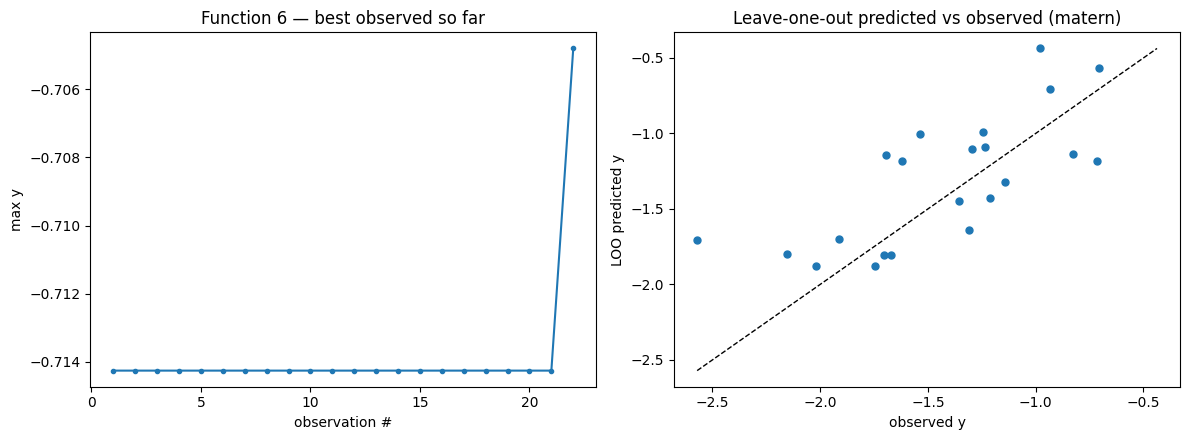

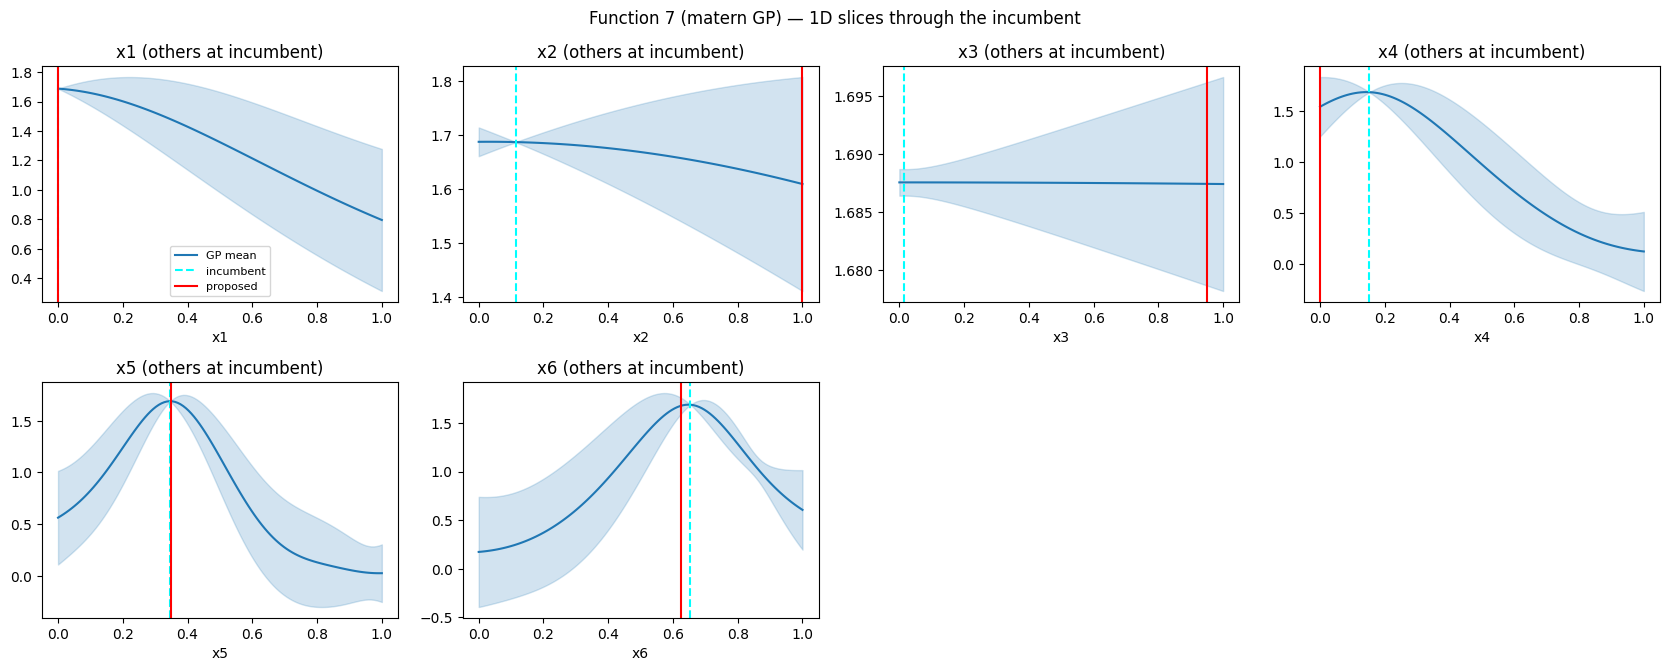

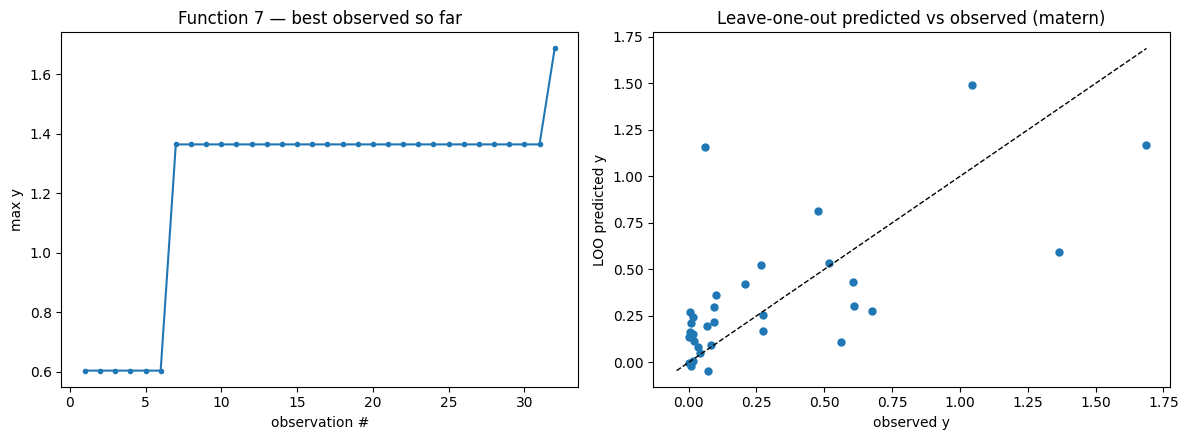

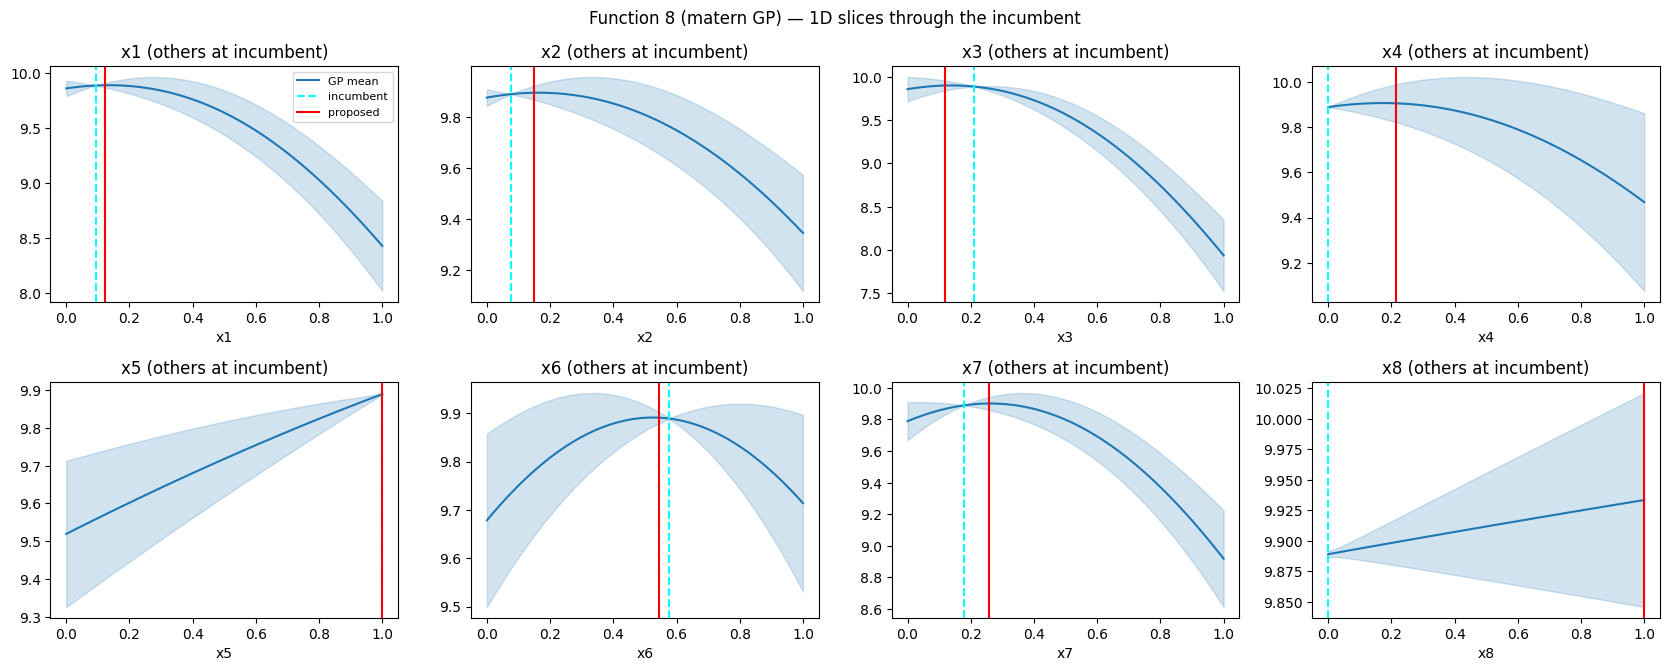

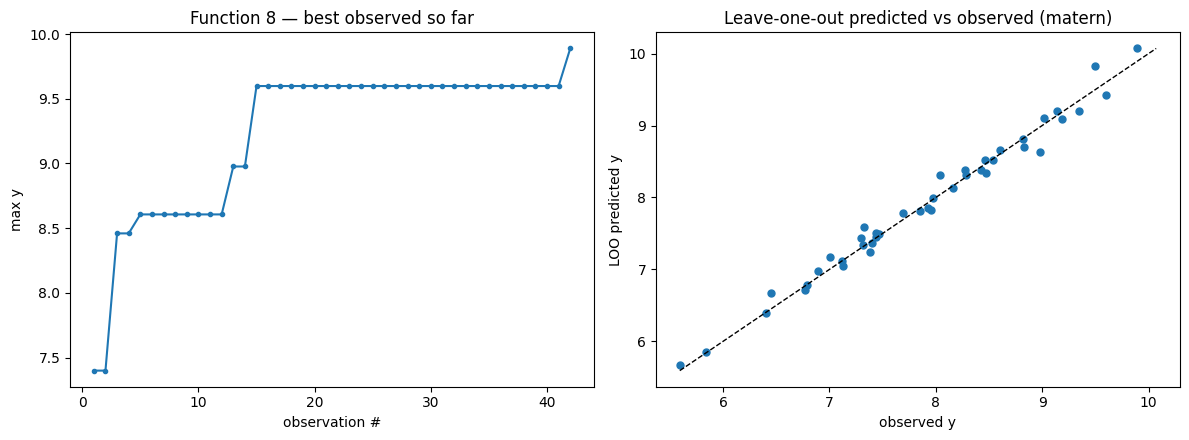

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r["model"]
    beta = PLAN[fid].get("beta", 2.0); xi = PLAN[fid].get("xi", 0.01)
    if m.d == 2:
        bo.plot_2d(m, beta=beta, xi=xi, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, beta=beta, xi=xi, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()

## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.077121-0.492948
f2:  0.744832-0.040605
f3:  0.883990-0.828081-0.850814
f4:  0.406314-0.415946-0.349326-0.438615
f5:  0.999999-0.999999-0.999999-0.999999
f6:  0.341538-0.000000-0.999999-0.999999-0.999999
f7:  0.000000-0.999999-0.949660-0.000000-0.348297-0.626119
f8:  0.121841-0.149133-0.117363-0.214605-0.999999-0.544963-0.258485-0.999999


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)
print("reflection ->", path)

reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week03.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# The scores the portal gave back for week 3's submissions.
# Already saved into data/fN.csv outside the notebook — kept here as a record of the round.
# returned_y = {
#     1: -3.907021515829406e-87,
#     2: 0.29603792653140965,
#     3: -0.053089354318077375,
#     4: 0.4426126372460897,
#     5: 8662.405001248297,
#     6: -1.9565511861280431,
#     7: 0.05253481251515244,
#     8: 9.9495299205974,
# }
# Comparison vs week-2 incumbents:
#   f1 ~0 (still flat — 3rd round of no signal)        f5 8662.4050 = 8662.4050  CONFIRMED DETERMINISTIC at (1,1,1,1)
#   f2 0.296 << 0.611 (AEI missed; noise still hard)   f6 -1.957 << -0.705 (UCB way off)
#   f3 -0.053 < -0.035 (slightly worse)                f7 0.053 << 1.688 (UCB crashed — surface is steep)
#   f4 0.443 < 0.540 (PI tightened to a worse spot)    f8 9.949 > 9.889  NEW BEST (MES delivers again, marginal)
# Net: only 1 new best (f8), 5 misses, 2 flat/confirmed. Weakest round; expected as we pivoted from explore to exploit.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
